# K-Means Clustering

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np

In [ ]:
X, y = make_blobs(n_samples=1000, centers=3, n_features=2)

In [ ]:
X

array([[ 6.98895547,  6.22213546],
       [ 6.15752007,  8.63906431],
       [ 7.49226533, -6.15860311],
       ...,
       [ 3.22559464, -7.53207059],
       [ 8.29362857,  7.62904535],
       [ 7.44805736, -5.33426753]])

In [ ]:
y

array([1, 1, 2, 2, 1, 1, 2, 0, 1, 1, 0, 2, 2, 0, 0, 1, 1, 0, 1, 1, 2, 0,
       1, 0, 2, 2, 2, 1, 1, 1, 2, 2, 0, 2, 2, 1, 2, 0, 2, 2, 2, 2, 2, 2,
       2, 1, 1, 1, 1, 0, 0, 2, 0, 1, 1, 2, 0, 0, 2, 1, 0, 2, 0, 1, 1, 1,
       0, 2, 1, 2, 2, 0, 1, 0, 1, 2, 2, 2, 2, 1, 2, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 2, 2, 1, 0, 2, 1, 1, 2, 2, 1, 1, 0, 2, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 2, 0, 0, 0, 1, 1, 2, 2, 0, 2, 2, 0, 0, 0, 1, 2, 1, 2,
       1, 0, 0, 2, 2, 1, 2, 0, 2, 0, 2, 0, 0, 1, 1, 0, 1, 2, 2, 1, 1, 1,
       0, 1, 1, 2, 0, 2, 1, 2, 0, 2, 2, 0, 1, 0, 1, 2, 0, 0, 1, 1, 0, 0,
       2, 2, 1, 2, 0, 1, 0, 2, 1, 1, 0, 0, 2, 2, 1, 0, 1, 2, 0, 1, 1, 0,
       1, 0, 2, 1, 1, 2, 0, 1, 1, 0, 0, 2, 2, 0, 0, 0, 0, 1, 2, 2, 2, 1,
       1, 1, 1, 2, 1, 1, 0, 1, 0, 2, 2, 2, 0, 2, 1, 2, 1, 0, 0, 1, 0, 2,
       2, 2, 0, 0, 0, 1, 1, 2, 0, 0, 0, 2, 2, 0, 1, 1, 1, 0, 0, 2, 2, 1,
       1, 1, 0, 2, 0, 2, 2, 0, 1, 1, 0, 2, 1, 1, 1, 1, 1, 0, 2, 0, 0, 1,
       1, 1, 1, 0, 0, 2, 0, 1, 0, 0, 2, 2, 2, 2, 0,

In [ ]:
X

array([[ 6.98895547,  6.22213546],
       [ 6.15752007,  8.63906431],
       [ 7.49226533, -6.15860311],
       ...,
       [ 3.22559464, -7.53207059],
       [ 8.29362857,  7.62904535],
       [ 7.44805736, -5.33426753]])

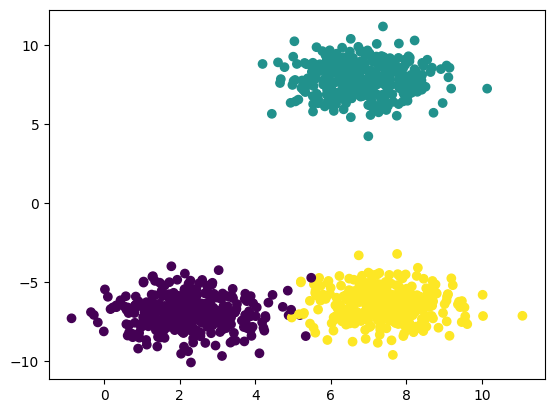

In [ ]:
plt.scatter(X[:,0], X[:,1], c=y)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_trained_scaled = scaler.fit_transform(X)
print(X_trained_scaled)

[[ 0.59812771  1.16199589]
 [ 0.26613956  1.51066582]
 [ 0.79909691 -0.62406879]
 ...
 [-0.90456415 -0.82220736]
 [ 1.1190774   1.36495891]
 [ 0.78144489 -0.50514885]]


In [ ]:
print(np.isnan(X_trained_scaled).sum())

0


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.33)

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.cluster import KMeans
wcss = []

for k in range(2,11):
  kmeans = KMeans(n_clusters=k, init='k-means++')
  kmeans.fit(X_train_scaled)
  wcss.append(kmeans.inertia_)

In [ ]:
wcss

[607.5161538990592,
 121.5860413736026,
 99.17425731671139,
 76.1067624203509,
 53.70518914159961,
 47.48909222760753,
 39.634791824024504,
 33.63776923206376,
 33.12414158021331]

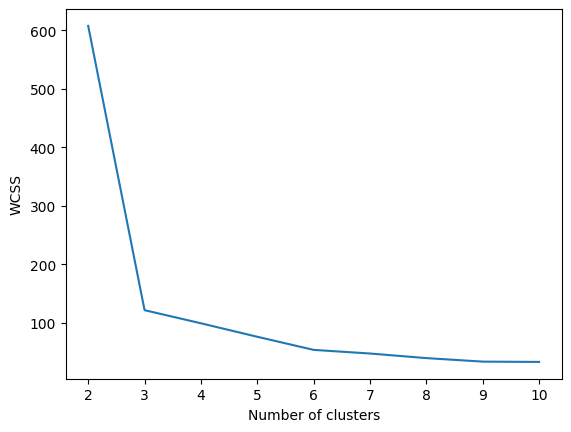

In [ ]:
# elbow method
plt.plot(range(2,11), wcss)
plt.xticks(np.arange(2,11,1))
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, init='k-means++')
kmeans.fit_predict(X_trained_scaled)

array([1, 1, 2, 2, 1, 1, 2, 0, 1, 1, 0, 2, 2, 0, 0, 1, 1, 0, 1, 1, 2, 0,
       1, 0, 2, 2, 2, 1, 1, 1, 2, 2, 0, 2, 2, 1, 2, 0, 2, 2, 2, 2, 2, 2,
       2, 1, 1, 1, 1, 0, 0, 2, 0, 1, 1, 2, 2, 0, 2, 1, 0, 2, 0, 1, 1, 1,
       0, 2, 1, 2, 2, 0, 1, 0, 1, 2, 2, 2, 2, 1, 2, 1, 0, 1, 0, 1, 0, 0,
       2, 0, 2, 2, 1, 0, 2, 1, 1, 2, 2, 1, 1, 0, 2, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 2, 0, 0, 0, 1, 1, 2, 2, 0, 2, 2, 0, 0, 0, 1, 2, 1, 2,
       1, 0, 0, 2, 2, 1, 2, 0, 2, 0, 2, 0, 0, 1, 1, 0, 1, 2, 2, 1, 1, 1,
       0, 1, 1, 2, 0, 2, 1, 2, 0, 2, 2, 0, 1, 0, 1, 2, 0, 0, 1, 1, 0, 0,
       2, 2, 1, 2, 0, 1, 0, 2, 1, 1, 0, 0, 2, 2, 1, 0, 1, 2, 0, 1, 1, 0,
       1, 0, 2, 1, 1, 2, 2, 1, 1, 0, 0, 2, 2, 0, 0, 0, 0, 1, 2, 2, 2, 1,
       1, 1, 1, 2, 1, 1, 0, 1, 0, 2, 2, 2, 0, 2, 1, 2, 1, 0, 0, 1, 0, 2,
       2, 2, 0, 0, 0, 1, 1, 2, 0, 0, 0, 2, 2, 0, 1, 1, 1, 0, 0, 2, 2, 1,
       1, 1, 0, 2, 0, 2, 2, 0, 1, 1, 0, 2, 1, 1, 1, 1, 1, 0, 2, 0, 0, 1,
       1, 1, 1, 0, 2, 2, 0, 1, 0, 0, 2, 2, 2, 2, 0,

In [ ]:
y_pred = kmeans.predict(X_test_scaled)

In [ ]:
y_pred

array([0, 0, 0, 2, 2, 1, 0, 2, 1, 2, 2, 1, 0, 2, 2, 2, 0, 1, 2, 0, 0, 0,
       2, 2, 0, 0, 0, 0, 0, 2, 0, 2, 2, 0, 2, 2, 0, 1, 2, 0, 2, 2, 1, 0,
       0, 0, 1, 0, 1, 2, 2, 2, 2, 1, 1, 2, 0, 0, 2, 1, 2, 2, 0, 1, 2, 0,
       0, 1, 0, 2, 2, 1, 0, 0, 0, 2, 0, 0, 0, 1, 1, 0, 2, 0, 1, 2, 2, 1,
       2, 2, 0, 0, 2, 0, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 2, 1, 0, 1, 1,
       1, 1, 0, 2, 2, 1, 2, 2, 1, 0, 0, 2, 1, 1, 1, 2, 2, 0, 0, 0, 0, 2,
       0, 0, 0, 0, 0, 1, 2, 2, 0, 0, 2, 0, 0, 2, 0, 0, 1, 1, 0, 0, 0, 0,
       2, 1, 1, 0, 0, 2, 0, 0, 1, 0, 1, 1, 2, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 2, 1, 1, 0, 2, 2, 2, 0, 0, 0, 2, 2, 1, 1, 1, 2, 0, 2, 1,
       1, 2, 2, 2, 0, 2, 1, 1, 1, 2, 1, 2, 2, 0, 1, 0, 2, 0, 1, 2, 1, 1,
       2, 1, 2, 2, 1, 2, 0, 1, 1, 1, 2, 2, 2, 0, 1, 2, 1, 1, 0, 1, 0, 1,
       1, 0, 2, 2, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1, 0, 2, 1, 1, 1, 2, 0, 0,
       1, 0, 0, 2, 1, 0, 0, 0, 0, 2, 2, 1, 0, 0, 2, 0, 1, 2, 1, 1, 1, 1,
       1, 1, 2, 2, 0, 0, 1, 1, 2, 2, 1, 1, 2, 1, 0,

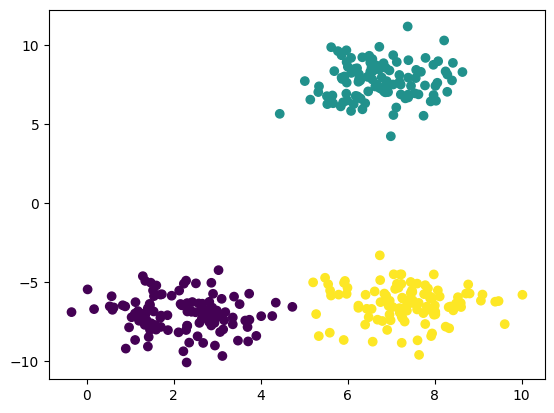

In [ ]:
plt.scatter(X_test[:,0], X_test[:,1],c=y_pred)

In [ ]:
!pip install kneed

In [ ]:
from kneed import KneeLocator

kl = KneeLocator(range(2,11), wcss, curve='convex', direction='decreasing')
kl.elbow

np.int64(3)

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_coefficients = []
for k in range(2,11):
  kmeans = KMeans(n_clusters=k, init='k-means++')
  kmeans.fit(X_train_scaled)
  score = silhouette_score(X_train_scaled, kmeans.labels_)
  silhouette_coefficients.append(score)

In [ ]:
silhouette_coefficients

[np.float64(0.5452861287444213),
 np.float64(0.7438421894716454),
 np.float64(0.631689531469979),
 np.float64(0.5318476210614829),
 np.float64(0.4487544586004652),
 np.float64(0.4300977285906599),
 np.float64(0.4221519456552818),
 np.float64(0.40299171214869006),
 np.float64(0.3909763120369983)]

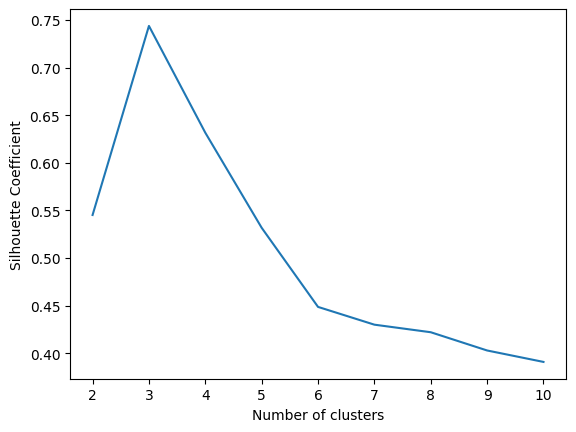

In [ ]:
plt.plot(range(2,11), silhouette_coefficients)
plt.xticks(np.arange(2,11,1))
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Coefficient')
plt.show()

# Hierarichial Clustering

In [ ]:
from sklearn import datasets
iris = datasets.load_iris()

In [ ]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [ ]:
df = pd.DataFrame(iris.data)
df.head()

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
df.columns = iris.feature_names

In [ ]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
X_scaled = scaler.fit_transform(df)

In [ ]:
X_scaled

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_scaled = pca.fit_transform(X_scaled)

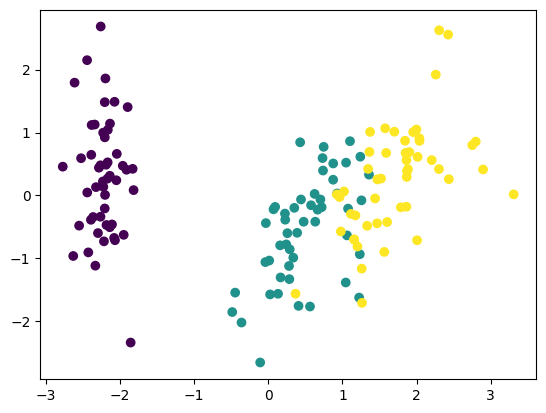

In [ ]:
plt.scatter(pca_scaled[:,0], pca_scaled[:,1], c=iris.target)

In [ ]:
import scipy.cluster.hierarchy as sc

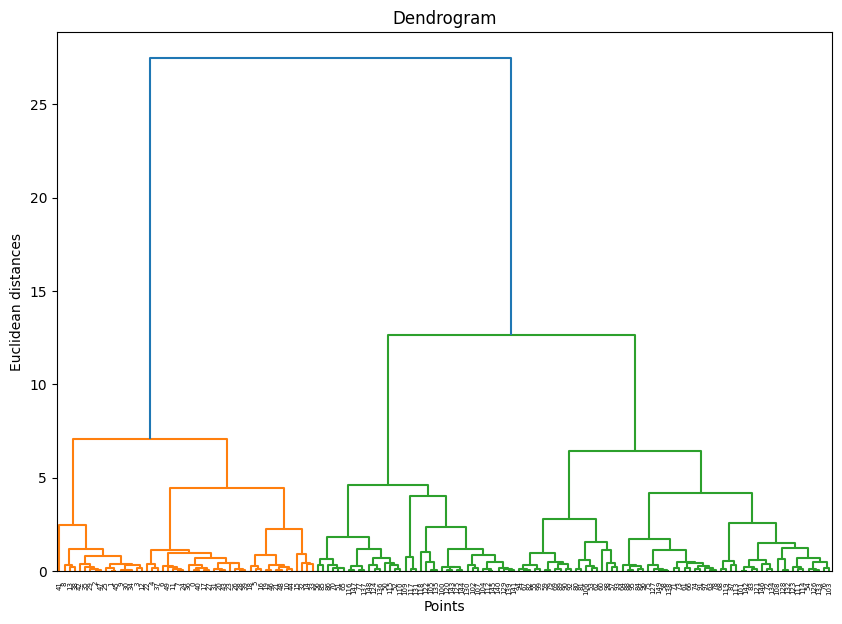

In [ ]:
plt.figure(figsize=(10,7))
plt.title('Dendograms')
sc.dendrogram(sc.linkage(pca_scaled, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Points')
plt.ylabel('Euclidean distances')
plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering
cluster = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
cluster.fit(pca_scaled)
cluster.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

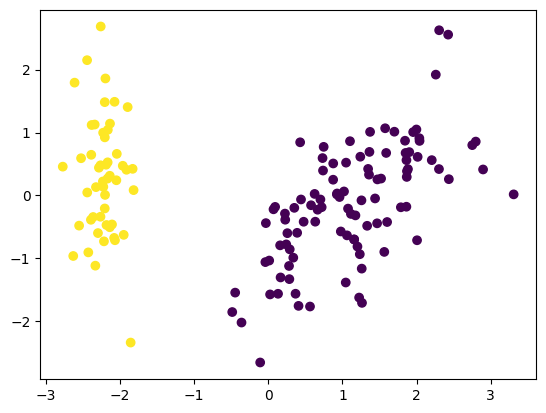

In [ ]:
plt.scatter(pca_scaled[:,0], pca_scaled[:,1], c = cluster.labels_)

# DBSCAN Clustering

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

In [ ]:
X, y = make_moons(n_samples=200, noise=0.1)

In [ ]:
X

array([[ 0.29677464,  0.76412097],
       [ 0.03724816,  0.2208579 ],
       [ 0.01051901,  0.11915562],
       [ 1.83058974, -0.22286524],
       [-0.16445747,  1.05488001],
       [ 0.74139111,  0.56401095],
       [-1.06089396,  0.41455618],
       [ 0.47795443,  0.84376902],
       [-0.5355374 ,  1.02990742],
       [-0.62581245,  0.76299953],
       [ 0.75895783, -0.37231301],
       [-0.85120312,  0.46821048],
       [ 1.97715806,  0.4174805 ],
       [ 0.10561012, -0.11621602],
       [-0.06635481,  0.39262811],
       [ 0.94730884,  0.39656075],
       [ 0.83088755,  0.28868958],
       [-0.1787941 ,  0.92654004],
       [-0.44319691,  0.58919428],
       [-0.68785249,  0.6898567 ],
       [ 0.28703496,  0.36671294],
       [ 1.91764976,  0.22294683],
       [ 0.53316179,  0.70648826],
       [ 0.21124614, -0.15674265],
       [ 1.96860387, -0.07116015],
       [ 0.92815911, -0.52491575],
       [ 1.3153369 , -0.62185889],
       [-0.9594809 ,  0.14918667],
       [ 1.10344611,

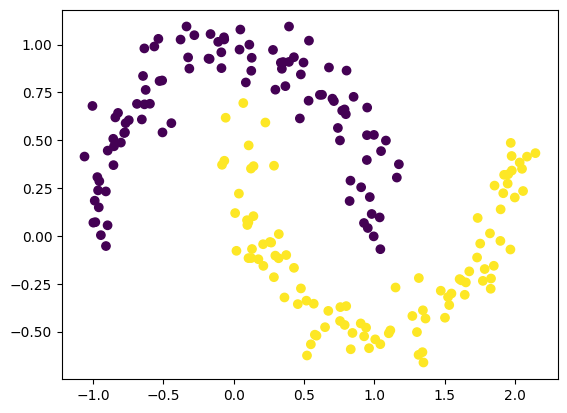

In [ ]:
plt.scatter(X[:,0], X[:,1], c = y)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
X_scaled = scaler.fit_transform(X)

In [ ]:
X_scaled

array([[-2.44966320e-01,  1.02848944e+00],
       [-5.42913757e-01, -6.66826509e-02],
       [-5.73599963e-01, -2.71705784e-01],
       [ 1.51591865e+00, -9.61190714e-01],
       [-7.74480399e-01,  1.61463491e+00],
       [ 2.65472291e-01,  6.25084667e-01],
       [-1.80362762e+00,  3.23796594e-01],
       [-3.69642126e-02,  1.18905312e+00],
       [-1.20049594e+00,  1.56429229e+00],
       [-1.30413554e+00,  1.02622870e+00],
       [ 2.85639641e-01, -1.26246469e+00],
       [-1.56289361e+00,  4.31959089e-01],
       [ 1.68418531e+00,  3.29691758e-01],
       [-4.64431317e-01, -7.46194976e-01],
       [-6.61854379e-01,  2.79591473e-01],
       [ 5.01874609e-01,  2.87519335e-01],
       [ 3.68218016e-01,  7.00602469e-02],
       [-7.90939464e-01,  1.35591245e+00],
       [-1.09448513e+00,  6.75852116e-01],
       [-1.37536015e+00,  8.78778986e-01],
       [-2.56147885e-01,  2.27348691e-01],
       [ 1.61586725e+00, -6.24715509e-02],
       [ 2.64161818e-02,  9.12306807e-01],
       [-3.

In [ ]:
dbscan = DBSCAN(eps=0.3)

In [ ]:
dbscan.fit(X_scaled)

DBSCAN(eps=0.3)

In [ ]:
dbscan.labels_

array([ 0,  1,  1,  1,  0,  0,  0,  0,  0,  0,  1,  0,  1,  1,  1,  0,  0,
        0,  0,  0,  1,  1,  0,  1,  1,  1,  1,  0,  1, -1,  1,  0,  0,  1,
        0,  1,  0,  0,  1,  1,  0,  1,  1,  1,  0,  0,  0,  0,  0,  1,  0,
        0,  0,  1,  0,  0,  0,  0,  1,  1,  1,  1,  0,  1,  0,  0,  0,  0,
        0,  1,  1,  0,  0,  1,  1,  1,  0,  0,  0,  0,  1,  1,  1,  1,  0,
        0,  1,  0,  0,  0,  0, -1,  1,  0,  1,  0,  0,  1,  1,  0,  1,  1,
        1,  1,  1,  0,  0,  1,  0,  0,  1,  0,  1,  0,  0,  1,  0,  0,  1,
        1,  0,  0,  1,  0,  0,  1,  1,  0,  1,  1,  0,  1,  1,  0,  1,  0,
        1,  1,  1,  1,  1,  0,  1,  1,  1,  1,  0,  0,  1,  1,  0,  0,  1,
        1,  0,  1,  0,  0,  0,  0,  1,  1,  1,  1,  0,  1,  1,  1,  0,  1,
        0,  0,  1,  0,  0,  0,  1,  0,  0,  1,  0,  1,  0,  1,  0,  0,  0,
        1,  0,  0,  0,  0,  0,  1,  0,  1,  0,  1,  1,  1])

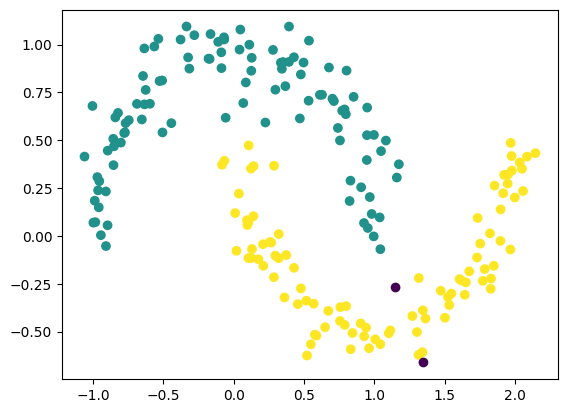

In [ ]:
plt.scatter(X[:,0], X[:,1], c = dbscan.labels_)